In [34]:
import pandas as pd
import numpy as np

cust_data = pd.read_csv("data/Mall_Customers.csv")
cust_data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [35]:
cust_data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [36]:
cust_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [37]:
cust_data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [38]:
cust_data.drop("CustomerID", axis=1)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [39]:
cust_data = cust_data.rename(columns={"Annual Income (k$)" : "Annual Income",
                             "Spending Score (1-100)" : "Spending Score"})
cust_data

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [40]:
cust_data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
cust_data["Annual Income"] = cust_data["Annual Income"]*1000
cust_data.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


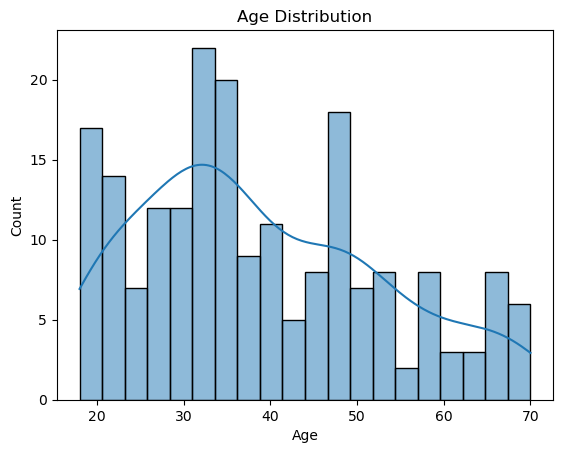

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution

plt.figure()
sns.histplot(cust_data["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

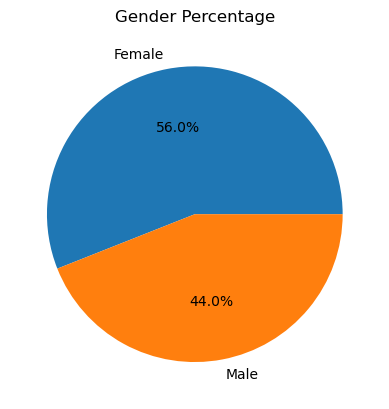

In [43]:
# Gender distribution

cust_data["Gender"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Gender Percentage")
plt.ylabel("")
plt.show()

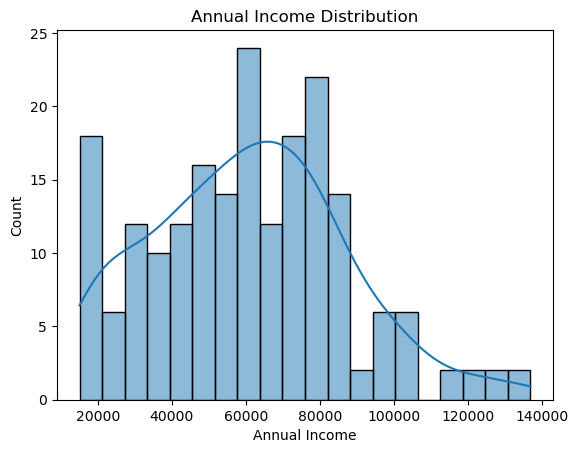

In [44]:
# Income distribution

plt.figure()
sns.histplot(cust_data["Annual Income"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

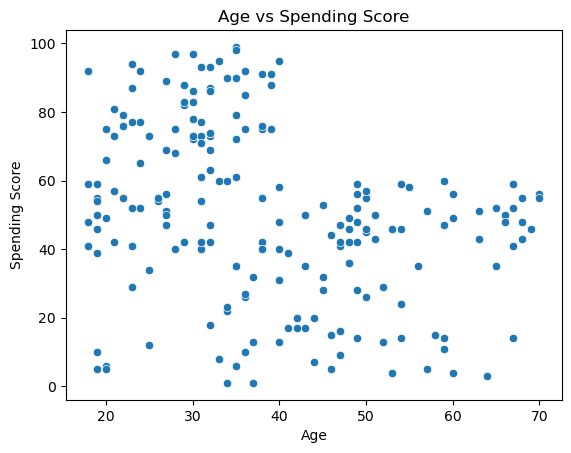

In [45]:
# Age vs spending score

plt.figure()
sns.scatterplot(x="Age", y="Spending Score", data=cust_data)
plt.title("Age vs Spending Score")
plt.show()

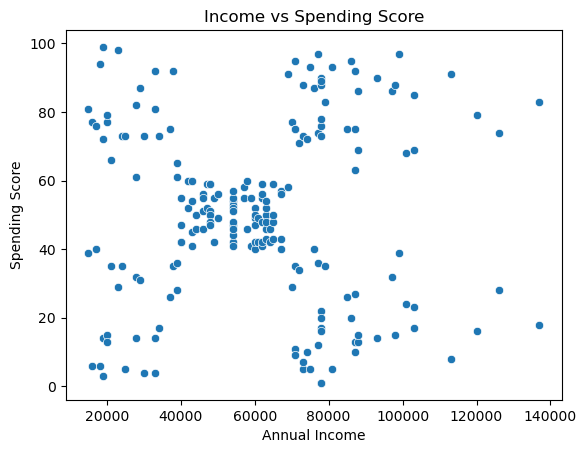

In [46]:
# Income vs spending score

plt.figure()
sns.scatterplot(x="Annual Income", y="Spending Score", data=cust_data)
plt.title("Income vs Spending Score")
plt.show()

In [47]:
cust_data["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [48]:
cust_data["Sex"] = np.where(cust_data["Gender"] == "Male", 1, 0)

In [49]:
cust_data["Sex"].value_counts()

Sex
0    112
1     88
Name: count, dtype: int64

In [50]:
cust_data.drop("Gender", axis=1, inplace=True)

In [51]:
cust_data.drop("CustomerID", axis=1, inplace=True)

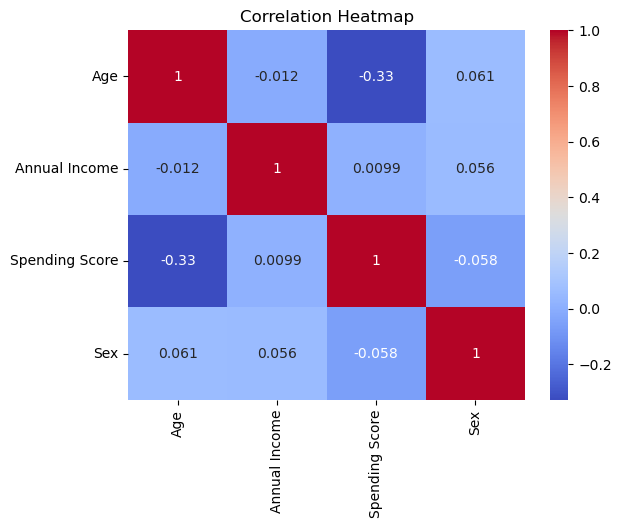

In [52]:
plt.figure()
sns.heatmap(cust_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [53]:
cust_data.isnull().sum()

Age               0
Annual Income     0
Spending Score    0
Sex               0
dtype: int64

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = cust_data[["Age", "Annual Income", "Spending Score"]]

X_scaled = scaler.fit_transform(X)

c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

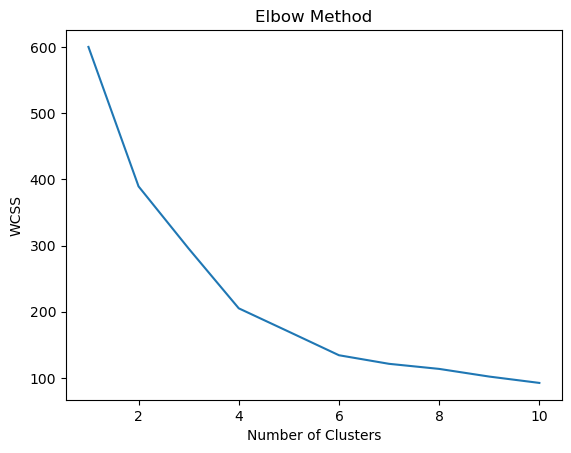

In [55]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# This measures -> How compact the clusters are
# Lower WCSS means = Points are closer to their cluster center
wcss = []   # Within Cluster Sum of Squares

for i in range(1,11): # Checking cluster numbers to know which one is best
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled) #Finds cluster centers, Assigns data points to clusters
    wcss.append(kmeans.inertia_) #kmeans.inertia_ gives = Total WCSS value for that k -> Total distance of all points from their cluster centers

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [56]:
kmeans = KMeans(n_clusters=5, random_state=42)#5 clusters. Why 5? Because elbow method suggested 5 is optimal
clusters = kmeans.fit_predict(X_scaled)

cust_data["Cluster"] = clusters

c:\Users\kisha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [57]:
# For each cluster, what is the average age?
# What is the average income?
# What is the average spending score?


cust_data.groupby("Cluster")[["Age", "Annual Income", "Spending Score"]].mean()

,Age,Annual Income,Spending Score
Cluster,,,
0,55.275862,47620.689655,41.706897
1,32.875000,86100.000000,81.525000
2,25.769231,26115.384615,74.846154
3,26.733333,54311.111111,40.911111
4,44.387097,89774.193548,18.483871


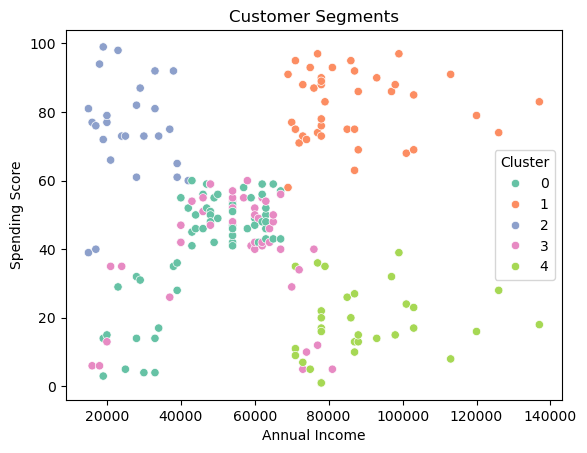

In [58]:
plt.figure()
sns.scatterplot(
    x="Annual Income",
    y="Spending Score",
    hue="Cluster",
    data=cust_data,
    palette="Set2"
)
plt.title("Customer Segments")
plt.show()

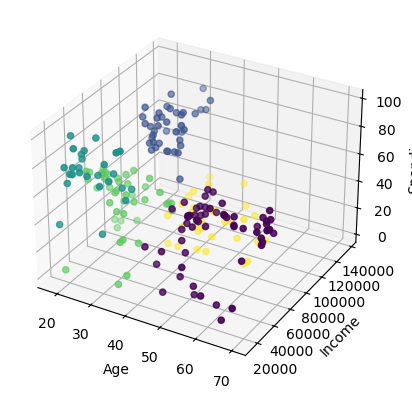

In [59]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    cust_data["Age"],
    cust_data["Annual Income"],
    cust_data["Spending Score"],
    c=cust_data["Cluster"]
)

ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending")
plt.show()

In [60]:
cluster_labels = {
    0: "Older Low Spenders",
    1: "High Income Low Spenders",
    2: "Young High Spenders",
    3: "Upper Class",
    4: "Budget Friendly Youth"
}

cust_data["Segment"] = cust_data["Cluster"].map(cluster_labels)

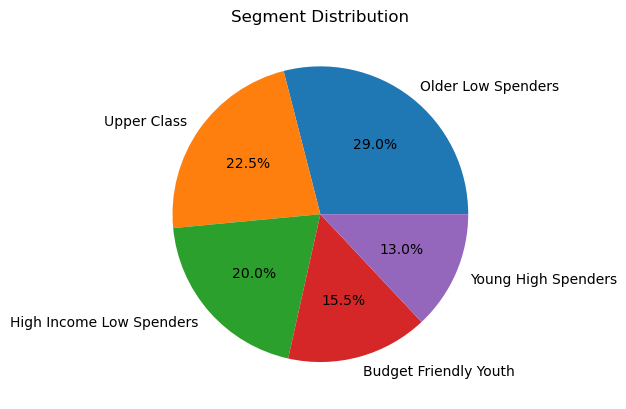

In [61]:
cust_data["Segment"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Segment Distribution")
plt.ylabel("")
plt.show()

In [62]:
cust_data.groupby("Segment")[["Age","Annual Income","Spending Score"]].mean()

,Age,Annual Income,Spending Score
Segment,,,
Budget Friendly Youth,44.387097,89774.193548,18.483871
High Income Low Spenders,32.875000,86100.000000,81.525000
Older Low Spenders,55.275862,47620.689655,41.706897
Upper Class,26.733333,54311.111111,40.911111
Young High Spenders,25.769231,26115.384615,74.846154


In [63]:
import joblib

joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']